In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

import sys
sys.path.insert(0, '../include')

from consts import mp, mn, m, hbar
from phase_shifts import compute_phase_shifts, fit_potential
from plot import plot_wavefunction, plot_wavefunctions
from sampling import TrainConfig
from scipy_eigensolver import solve_1channel
from training import train_Rayleigh, train_Rayleigh_PDE
from validation import validate, print_metrics

## Two-range Yukawa potential

We use a two-range Yukawa (also called a soft-core potential) with a repulsive short-range term and an attractive long-range term:

$$
V(r;\,V_R,a_R,V_A,a_A) = \frac{V_R\,e^{-r/a_R} - V_A\,e^{-r/a_A}}{r}
$$

where $V_R,V_A > 0$ (MeV·fm), $a_R < a_A$ (fm). The four parameters are fitted to the $^3S_1$ np phase shifts of Stoks *et al.*, PRC 48 (1993) 792, Table V.

In [13]:
# Stoks et al., PRC 48 (1993) 792, Table V
Tlab   = np.array([1, 5, 10, 25, 50, 100, 150, 200, 250, 300, 350], dtype=float)
np_3S1 = np.array([147.747, 118.178, 102.611, 80.63, 62.77, 43.23, 30.72, 21.22, 13.39, 6.6, 0.502])

# T_lab -> relative wavenumber  (non-relativistic CM)
T_rel = mn / (mp + mn) * Tlab
k_exp = np.sqrt(2.0 * m * T_rel) / hbar

mask_lo = Tlab <= 100
k_lo, delta_lo = k_exp[mask_lo], np_3S1[mask_lo]

# Two-range Yukawa potential template
def V_2Y(r, VR, aR, VA, aA):
    r_safe = np.maximum(r, 1e-2)
    return (VR * np.exp(-r_safe / aR) - VA * np.exp(-r_safe / aA)) / r_safe

# Fit — starting point from a coarse grid scan
params_opt, res = fit_potential(
    V_2Y,
    params_init=[500.0, 0.3, 100.0, 2.0],
    k_data=k_lo, delta_data=delta_lo,
    bounds=[(50, 10000), (0.1, 0.8), (10, 500), (0.5, 4.0)],
    n_bound_states=1,
)
VR, aR, VA, aA = params_opt

print(f'Fitted parameters:')
print(f'  VR = {VR:.3f} MeV·fm    aR = {aR:.4f} fm   (repulsive core)')
print(f'  VA = {VA:.3f} MeV·fm    aA = {aA:.4f} fm   (attractive tail)')
print(f'  chi2 = {res.fun:.4g}   converged: {res.success}')
print()

# Point-by-point residuals
delta_fit = compute_phase_shifts(lambda r: V_2Y(r, *params_opt), k_exp, n_bound_states=1)
print(f'{"Tlab":>6}  {"data":>8}  {"fit":>8}  {"resid":>7}')
for Tl, de, df in zip(Tlab, np_3S1, delta_fit):
    print(f'{Tl:6.0f}  {de:8.3f}  {df:8.3f}  {df-de:+7.3f}')

Fitted parameters:
  VR = 8052.848 MeV·fm    aR = 0.1470 fm   (repulsive core)
  VA = 500.000 MeV·fm    aA = 0.6145 fm   (attractive tail)
  chi2 = 0.2815   converged: False

  Tlab      data       fit    resid
     1   147.747   147.930   +0.183
     5   118.178   118.285   +0.107
    10   102.611   102.559   -0.052
    25    80.630    80.348   -0.282
    50    62.770    62.540   -0.230
   100    43.230    43.548   +0.318
   150    30.720    31.716   +0.996
   200    21.220    22.927   +1.707
   250    13.390    15.856   +2.466
   300     6.600     9.900   +3.300
   350     0.502     4.732   +4.230


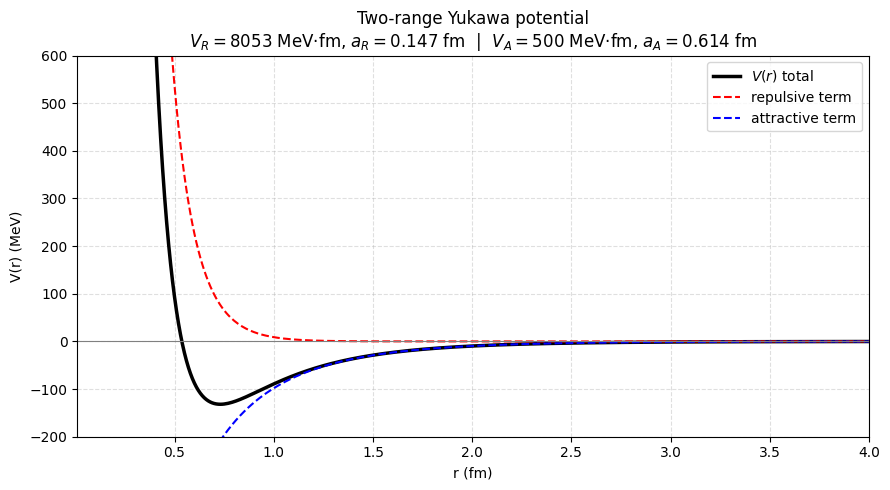

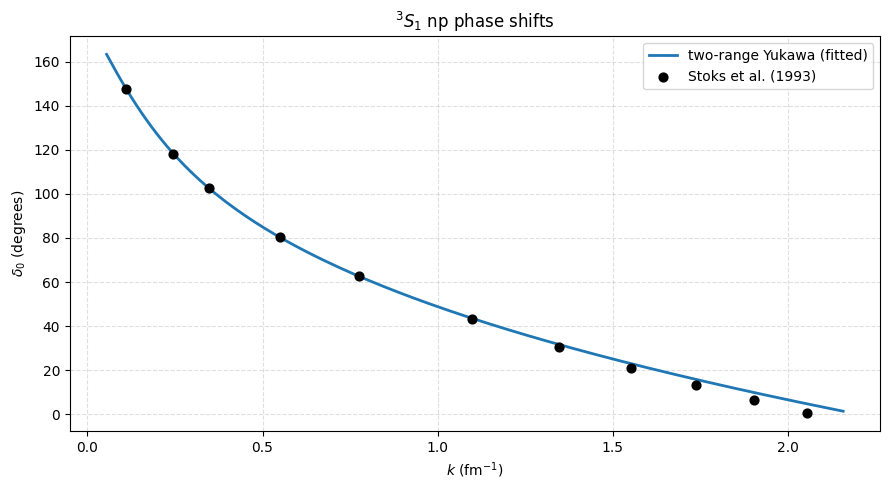

In [14]:
r_plot = np.linspace(0.01, 4.0, 400)
V_vals = V_2Y(r_plot, VR, aR, VA, aA)
V_rep  =  VR * np.exp(-r_plot / aR) / r_plot   # repulsive part alone
V_att  = -VA * np.exp(-r_plot / aA) / r_plot   # attractive part alone

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(r_plot, V_vals, 'k',  lw=2.5, label='$V(r)$ total')
ax.plot(r_plot, V_rep,  '--', lw=1.5, color='red',  label='repulsive term')
ax.plot(r_plot, V_att,  '--', lw=1.5, color='blue', label='attractive term')
ax.axhline(0, color='gray', lw=0.8)
ax.set_xlim(0.01, 4.0)
ax.set_ylim(-200, 600)
ax.set_xlabel('r (fm)')
ax.set_ylabel('V(r) (MeV)')
ax.set_title(
    f'Two-range Yukawa potential\n'
    f'$V_R={VR:.0f}$ MeV·fm, $a_R={aR:.3f}$ fm  |  '
    f'$V_A={VA:.0f}$ MeV·fm, $a_A={aA:.3f}$ fm'
)
ax.legend()
ax.grid(True, ls='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Phase shift comparison
k_dense = np.linspace(k_exp[0] * 0.5, k_exp[-1] * 1.05, 150)
delta_dense = compute_phase_shifts(lambda r: V_2Y(r, *params_opt), k_dense, n_bound_states=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(k_dense, delta_dense, lw=2, label='two-range Yukawa (fitted)')
ax.scatter(k_exp, np_3S1, color='black', zorder=5, s=40, label='Stoks et al. (1993)')
ax.set_xlabel(r'$k$ (fm$^{-1}$)')
ax.set_ylabel(r'$\delta_0$ (degrees)')
ax.set_title(r'$^3S_1$ np phase shifts')
ax.legend()
ax.grid(True, ls='--', alpha=0.4)
plt.tight_layout()
plt.show()

## Solve with scipy

Use the shooting method to find the bound-state energy and wavefunction of the fitted potential.

Ground state energy E = -2.274414 MeV
Scipy bound state energy: -2.274414 MeV
Experimental (deuteron):  -2.2246 MeV


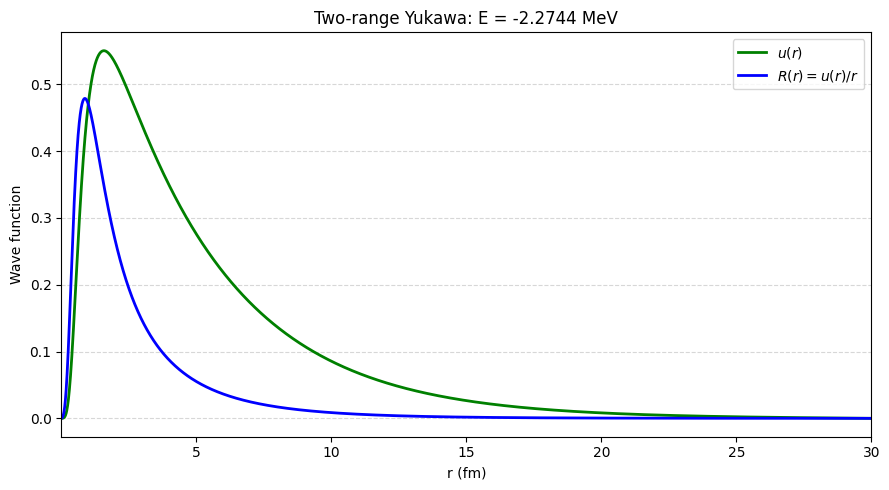

In [24]:
r_min = 1e-4
r_max = 30.0
r = np.linspace(r_min, r_max, 5000)

def V_scipy(r):
    return V_2Y(r, VR, aR, VA, aA)

E_scipy, u_scipy, R_scipy = solve_1channel(V_scipy, r)
print(f'Scipy bound state energy: {E_scipy:.6f} MeV')
print(f'Experimental (deuteron):  -2.2246 MeV')

plot_wavefunction(r, u_scipy, R_scipy, E_scipy, title='Two-range Yukawa')

## Neural network

Define a neural network $N_\theta(r)$ that approximates the radial wave function via the ansatz
$$
u_\theta(r) = r\,e^{-\alpha r}\,N_\theta(r), \quad \alpha = 0.25\text{ fm}^{-1}.
$$
The network input is rescaled from $[0, r_{\max}]$ to $[-1, 1]$. The potential parameters $(V_R, a_R, V_A, a_A)$ are stored as fixed buffers.

In [19]:
class RadialNet(nn.Module):
    def __init__(self, VR, aR, VA, aA, hidden_dim=64, num_layers=3, alpha=0.25, energy_init=-3.0):
        super().__init__()
        layers = [nn.Linear(1, hidden_dim), nn.Tanh()]
        for _ in range(num_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers.append(nn.Linear(hidden_dim, 1))
        self.net = nn.Sequential(*layers)

        self.register_buffer('alpha', torch.tensor(float(alpha)))
        self.register_buffer('VR', torch.tensor(float(VR)))
        self.register_buffer('aR', torch.tensor(float(aR)))
        self.register_buffer('VA', torch.tensor(float(VA)))
        self.register_buffer('aA', torch.tensor(float(aA)))
        self.energy = nn.Parameter(torch.tensor([energy_init], dtype=torch.float32))

        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.dtype  = torch.float32
        self.r_min  = r_min
        self.r_max  = r_max
        self.R      = None   # no discontinuity in the potential

    def forward(self, r):
        x = 2.0 * r / self.r_max - 1.0
        return r * torch.exp(-self.alpha * r) * self.net(x)

    def potential(self, r):
        r_safe = torch.clamp(r, min=1e-2)
        return (self.VR * torch.exp(-r_safe / self.aR)
              - self.VA * torch.exp(-r_safe / self.aA)) / r_safe

## Train with Rayleigh energy only

In [44]:
cfg = TrainConfig()
cfg.n_rayleigh = 10000

model = RadialNet(VR, aR, VA, aA)

history = train_Rayleigh(model, cfg, stop=1e-4)

{'step': 1, 'loss': 22.580020904541016, 'rayleigh': 13.434277534484863, 'norm_loss': 0.9145665168762207, 'boundary_loss': 7.856435331632383e-06, 'E': 13.434277534484863}
{'step': 500, 'loss': 0.042061809450387955, 'rayleigh': 0.0020618257112801075, 'norm_loss': 6.0786747781094164e-05, 'boundary_loss': 0.003939211834222078, 'E': 0.0020618257112801075}
{'step': 1000, 'loss': -1.274484634399414, 'rayleigh': -1.3147574663162231, 'norm_loss': 0.004024016670882702, 'boundary_loss': 3.260497123847017e-06, 'E': -1.3147574663162231}
{'step': 1500, 'loss': -1.4087245464324951, 'rayleigh': -1.409999132156372, 'norm_loss': 0.00012524538033176214, 'boundary_loss': 2.216468374172109e-06, 'E': -1.409999132156372}
{'step': 2000, 'loss': -1.6686350107192993, 'rayleigh': -1.7161991596221924, 'norm_loss': 0.004756420385092497, 'boundary_loss': 3.9589775902015845e-09, 'E': -1.7161991596221924}
{'step': 2500, 'loss': -2.5386674404144287, 'rayleigh': -2.5388965606689453, 'norm_loss': 2.2793108655605465e-05,

In [45]:
metrics, u_nn, R_nn = validate(r, u_scipy, R_scipy, E_scipy, model)
print_metrics(metrics)

  rayleigh_energy: -2.2346485
  norm_loss: 9.6065378e-08
  pde_loss: 44.49448
  u_rmax: -0.0012531499
  l2: 1.9992955
  learned_energy: -2.0882812
  energy_error: 0.18613235


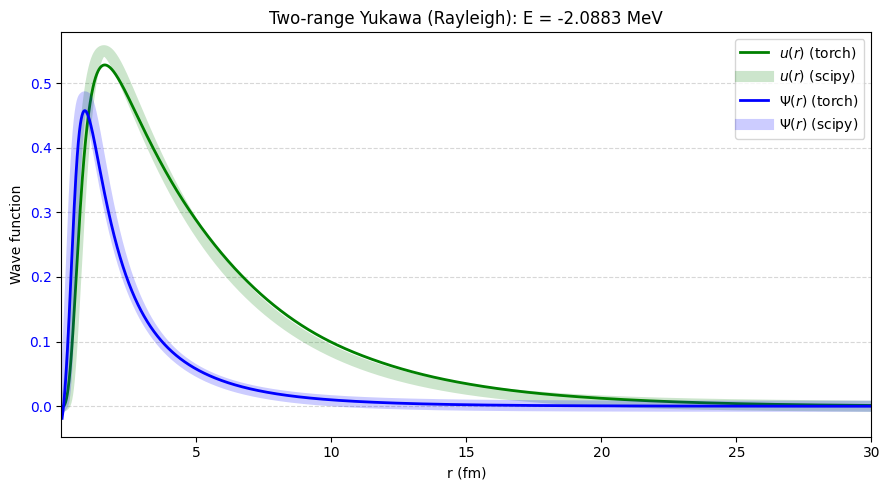

In [47]:
plot_wavefunctions(r, u_scipy, R_scipy, -u_nn, -R_nn, metrics['learned_energy'],
                   title='Two-range Yukawa (Rayleigh)')

## Train with both Rayleigh and PDE terms

In [40]:
cfg2 = TrainConfig()
cfg2.n_origin   = 3000
cfg2.n_pde      = 1000
cfg2.origin_width = 0.6
cfg.n_rayleigh = 10000

model2 = RadialNet(VR, aR, VA, aA)

history2 = train_Rayleigh_PDE(model2, cfg2, stop=1e-3)

{'step': 1, 'loss': 8.456978797912598, 'rayleigh': 5.3717122077941895, 'pde_loss': 132237.34375, 'match_loss': 70.08555603027344, 'norm_loss': 0.3085213601589203, 'boundary_loss': 5.263371804176131e-06, 'E': -3.0, 'lambda_pde': 0.0, 'lambda_match': 0.0}
{'step': 500, 'loss': 0.015180211514234543, 'rayleigh': -0.03827090561389923, 'pde_loss': 1892.8612060546875, 'match_loss': 8.771839141845703, 'norm_loss': 0.0013357576681300998, 'boundary_loss': 0.004009353928267956, 'E': -3.0, 'lambda_pde': 0.0, 'lambda_match': 0.0}
{'step': 1000, 'loss': -0.7498799562454224, 'rayleigh': -1.0470514297485352, 'pde_loss': 40682.7109375, 'match_loss': 3.8140082359313965, 'norm_loss': 0.02971668355166912, 'boundary_loss': 4.63944559214724e-07, 'E': -3.0, 'lambda_pde': 0.0, 'lambda_match': 0.0}
{'step': 1500, 'loss': -2.8626608848571777, 'rayleigh': -2.934905767440796, 'pde_loss': 32341.056640625, 'match_loss': 0.0042372592724859715, 'norm_loss': 0.007220427040010691, 'boundary_loss': 4.062431344209472e-06

In [41]:
metrics2, u_nn2, R_nn2 = validate(r, u_scipy, R_scipy, E_scipy, model2)
print_metrics(metrics2)

  rayleigh_energy: -2.0638213
  norm_loss: 0.0014586679
  pde_loss: 5.7925806
  u_rmax: -0.0040554311
  l2: 0.16530121
  learned_energy: -1.9871546
  energy_error: 0.2872589


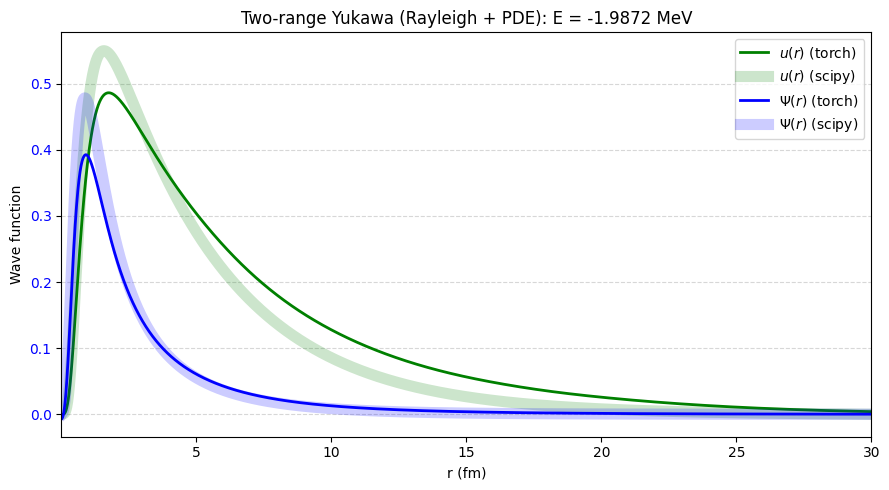

In [42]:
plot_wavefunctions(r, u_scipy, R_scipy, u_nn2, R_nn2, metrics2['learned_energy'],
                   title='Two-range Yukawa (Rayleigh + PDE)')